#Cài đặt

In [ ]:
!pip install kaggle gensim pyLDAvis wordcloud plotly bertopic sentence-transformers umap-learn hdbscan scikit-learn -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 72.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 13.3 MB/s eta 0:00:00


In [ ]:
import os, json, glob

KAGGLE_USERNAME = "caobolinh"           # ← đổi username Kaggle
KAGGLE_TOKEN    = "KGAT_ded45b3c886c451c3c35756237e7660e"  # ← đổi API token

os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump({'username': KAGGLE_USERNAME, 'key': KAGGLE_TOKEN}, f)
os.chmod('/root/.kaggle/kaggle.json', 0o600)
print('✅ Kaggle API OK')

✅ Kaggle API OK


In [ ]:
# ── Dataset A: yasserh (~1k review) ──────────────────────────────────────
!kaggle datasets download -d yasserh/amazon-product-reviews-dataset \
    -p /content/data_a --unzip -q
print('Dataset A:', glob.glob('/content/data_a/*.csv'))

# ── Dataset B: Amazon Fine Food Reviews ───────────────────────────────────
!kaggle datasets download -d snap/amazon-fine-food-reviews \
    -p /content/data_b --unzip -q
print('Dataset B:', glob.glob('/content/data_b/*.csv'))

Dataset URL: https://www.kaggle.com/datasets/yasserh/amazon-product-reviews-dataset
License(s): CC0-1.0
Dataset A: ['/content/data_a/7817_1.csv']
Dataset URL: https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews
License(s): CC0-1.0
Dataset B: ['/content/data_b/Reviews.csv']


#Import thư viện và cấu hình

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import re, warnings, pickle
from collections import Counter
warnings.filterwarnings('ignore')

# NLP
import nltk
for pkg in ['punkt','punkt_tab','stopwords','wordnet',
            'averaged_perceptron_tagger','averaged_perceptron_tagger_eng']:
    nltk.download(pkg, quiet=True)
from nltk.corpus import stopwords as nltk_stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Topic Modeling
from gensim import corpora
from gensim.models import LdaModel, CoherenceModel
from gensim.models.phrases import Phrases, Phraser   # 🆕 Bigram/Trigram
import pyLDAvis, pyLDAvis.gensim_models as gensimvis
from wordcloud import WordCloud

# 🆕 Đánh giá mô hình
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support,
                             confusion_matrix, classification_report,
                             silhouette_score, adjusted_rand_score)
from sklearn.preprocessing import LabelEncoder

# ── Font & style toàn cục ─────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':12,
    'axes.titlesize':14,'axes.titleweight':'bold',
    'axes.labelsize':12,'xtick.labelsize':10,'ytick.labelsize':10,
    'legend.fontsize':10,'figure.titlesize':15,
    'axes.spines.top':False,'axes.spines.right':False,
})
PALETTE     = ['#4C72B0','#DD8452','#55A868','#C44E52','#8172B3',
               '#937860','#DA8BC3','#8C8C8C','#CCB974','#64B5CD']
STAR_COLORS = ['#e74c3c','#e67e22','#f1c40f','#2ecc71','#3498db']
SENT_COLORS = {'Tích cực':'#2ecc71','Trung lập':'#f1c40f','Tiêu cực':'#e74c3c'}
sns.set_palette(PALETTE)
print('✅ Thư viện & font OK')

✅ Thư viện & font OK


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Patch warning jupyter_client (tuỳ chọn — nếu Colab báo warning datetime)
import warnings
warnings.filterwarnings('ignore')

import sys
if not sys.warnoptions:
    import os
    os.environ["PYTHONWARNINGS"] = "ignore"

try:
    import jupyter_client.session as jcs
    import datetime
    def _patched_utcnow():
        return datetime.datetime.now(datetime.timezone.utc).replace(tzinfo=None)
    jcs.utcnow = _patched_utcnow
except Exception:
    pass

print('✅ Đã patch jupyter_client warning')

✅ Đã patch jupyter_client warning


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packag

#Đọc và làm giàu dữ liệu

In [ ]:
# ── 3.1  Dataset A: yasserh ──────────────────────────────────────────────
path_a  = glob.glob('/content/data_a/*.csv')[0]
df_a    = pd.read_csv(path_a, low_memory=False)

df_a = df_a[['reviews.text','reviews.rating','name','brand','categories']].dropna(
    subset=['reviews.text','reviews.rating']).copy()
df_a.columns = ['review_text','rating','product_name','brand','category']
df_a['source']      = 'Dataset A (yasserh)'
df_a['review_text'] = df_a['review_text'].astype(str)
df_a['rating']      = pd.to_numeric(df_a['rating'], errors='coerce')
df_a = df_a.dropna(subset=['rating'])
df_a['rating']      = df_a['rating'].astype(int)
df_a['word_count']  = df_a['review_text'].apply(lambda x: len(str(x).split()))

print(f'Dataset A raw: {len(df_a):,} reviews')
df_a.head(2)

Dataset A raw: 1,177 reviews


,review_text,rating,product_name,brand,category,source,word_count
0,I initially had trouble deciding between the p...,5,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",Dataset A (yasserh),193
1,Allow me to preface this with a little history...,5,Kindle Paperwhite,Amazon,"Amazon Devices,mazon.co.uk",Dataset A (yasserh),272


In [ ]:
# ── 3.2  Đọc Dataset B (Amazon Fine Food Reviews) ───────────────────────
path_b   = glob.glob('/content/data_b/*.csv')[0]
df_b_raw = pd.read_csv(path_b, low_memory=False)
print('Columns:', df_b_raw.columns.tolist())
print('Shape  :', df_b_raw.shape)
df_b_raw.head(2)

Columns: ['Id', 'ProductId', 'UserId', 'ProfileName', 'HelpfulnessNumerator', 'HelpfulnessDenominator', 'Score', 'Time', 'Summary', 'Text']
Shape  : (568454, 10)


,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...


In [ ]:
# ── 3.3  Chuẩn hóa Dataset B (Amazon Fine Food Reviews) ────────────────
rev_col_b  = 'Text'
rat_col_b  = 'Score'
name_col_b = 'ProductId'

cols_b = {rev_col_b:'review_text', rat_col_b:'rating', name_col_b:'product_name'}
df_b = df_b_raw[list(cols_b.keys())].dropna(subset=[rev_col_b, rat_col_b]).copy()
df_b.rename(columns=cols_b, inplace=True)
for c in ['brand','category']: df_b[c] = 'Unknown'
df_b['source']      = 'Dataset B (Fine Food)'
df_b['review_text'] = df_b['review_text'].astype(str)
df_b['rating']      = pd.to_numeric(df_b['rating'], errors='coerce')
df_b = df_b.dropna(subset=['rating'])
df_b['rating']      = df_b['rating'].astype(int)

if len(df_b) > 50000:
    df_b = df_b.sample(50000, random_state=42).reset_index(drop=True)
    print('Lấy mẫu 50,000 từ Dataset B')

df_b['word_count'] = df_b['review_text'].apply(lambda x: len(str(x).split()))

print(f'✅ Dataset B: {len(df_b):,} reviews')
print(f'Rating range: {df_b["rating"].min()}–{df_b["rating"].max()}')
df_b.head(2)

Lấy mẫu 50,000 từ Dataset B
✅ Dataset B: 50,000 reviews
Rating range: 1–5


,review_text,rating,product_name,brand,category,source,word_count
0,Having tried a couple of other brands of glute...,5,B000EVG8J2,Unknown,Unknown,Dataset B (Fine Food),84
1,My cat loves these treats. If ever I can't fin...,5,B0000BXJIS,Unknown,Unknown,Dataset B (Fine Food),99


In [ ]:
# ── 3.4  Merge thành dataset tổng hợp ────────────────────────────────────
df_merged = pd.concat([df_a, df_b], ignore_index=True)
df_merged = df_merged[
    (df_merged['word_count'] >= 5) & (df_merged['word_count'] <= 500)
].reset_index(drop=True)

# 🆕 Sentiment label làm proxy ground truth
df_merged['sentiment'] = df_merged['rating'].apply(
    lambda r: 'Tích cực' if r >= 4 else ('Tiêu cực' if r <= 2 else 'Trung lập'))

print('='*50)
print(f'Dataset A  : {len(df_a):,} reviews')
print(f'Dataset B  : {len(df_b):,} reviews')
print(f'Merged     : {len(df_merged):,} reviews')
print(f'Rating range: {df_merged["rating"].min()}–{df_merged["rating"].max()}')
print()
print('Phân phối Sentiment (proxy label):')
print(df_merged['sentiment'].value_counts())

Dataset A  : 1,177 reviews
Dataset B  : 50,000 reviews
Merged     : 50,912 reviews
Rating range: 1–5

Phân phối Sentiment (proxy label):
sentiment
Tích cực     39892
Tiêu cực      7128
Trung lập     3892
Name: count, dtype: int64


#EDA song song

In [ ]:
# 4.1 — So sánh phân phối rating A vs B
def rating_dist(df, label):
    rc = df['rating'].value_counts().sort_index().reset_index()
    rc.columns = ['rating','count']
    rc['pct']  = rc['count']/rc['count'].sum()*100
    rc['label'] = label
    return rc

rc_a = rating_dist(df_a, 'Dataset A')
rc_b = rating_dist(df_b, 'Dataset B')

fig = make_subplots(
    rows=1, cols=3,
    specs=[[{'type':'bar'},{'type':'bar'},{'type':'pie'}]],
    subplot_titles=['Dataset A — Phân phối rating',
                    'Dataset B — Phân phối rating',
                    'Merged — Tỷ lệ rating']
)
for row_df, col, name in [(rc_a,1,'A'),(rc_b,2,'B')]:
    fig.add_trace(go.Bar(
        x=row_df['rating'].apply(lambda x: f'{x} sao'),
        y=row_df['count'], name=name,
        marker_color=STAR_COLORS[:len(row_df)],
        text=row_df['pct'].apply(lambda x: f'{x:.1f}%'),
        textposition='outside',
        hovertemplate='%{x}: %{y:,}<extra></extra>'
    ), row=1, col=col)

rc_m = rating_dist(df_merged,'Merged')
fig.add_trace(go.Pie(
    labels=rc_m['rating'].apply(lambda x: f'{x} sao'),
    values=rc_m['count'], hole=0.4,
    marker_colors=STAR_COLORS[:len(rc_m)],
    hovertemplate='%{label}: %{value:,} (%{percent})<extra></extra>'
), row=1, col=3)

fig.update_layout(title_text='EDA — Phân Phối Rating (Song Song 2 Dataset)',
    font_family='Arial', font_size=12,
    plot_bgcolor='white', paper_bgcolor='white',
    showlegend=False, height=420)
fig.update_yaxes(showgrid=True, gridcolor='#eee')
fig.write_html('/content/eda_rating_compare.html')
fig.show()

In [ ]:
# 4.2 — So sánh độ dài review A vs B
for _df in (df_a, df_b, df_merged):
    if 'word_count' not in _df.columns:
        _df['word_count'] = _df['review_text'].astype(str).apply(lambda x: len(x.split()))

def wc_stats(df):
    return df['word_count'].describe()[['mean','50%','max']].round(1)

print('Thống kê độ dài review (số từ):')
print(pd.DataFrame({'Dataset A': wc_stats(df_a),
                    'Dataset B': wc_stats(df_b),
                    'Merged'   : wc_stats(df_merged)}))

fig = go.Figure()
for df_tmp, name, color in [(df_a,'Dataset A','#4C72B0'),
                             (df_b,'Dataset B','#DD8452')]:
    fig.add_trace(go.Histogram(
        x=df_tmp['word_count'].clip(upper=300), name=name,
        marker_color=color, opacity=0.65, nbinsx=50,
        hovertemplate=name+' — %{x} từ: %{y:,}<extra></extra>'
    ))
fig.update_layout(title='So Sánh Phân Phối Độ Dài Review (A vs B)',
    barmode='overlay', xaxis_title='Số từ', yaxis_title='Số review',
    font_family='Arial', font_size=12,
    plot_bgcolor='white', paper_bgcolor='white', height=400)
fig.update_yaxes(showgrid=True, gridcolor='#eee')
fig.write_html('/content/eda_wordcount_compare.html')
fig.show()

Thống kê độ dài review (số từ):
      Dataset A  Dataset B  Merged
mean      134.9       80.0    78.2
50%        54.0       56.0    56.0
max      3601.0     1901.0   500.0


#Tiền xử lý văn bản

In [ ]:
# 5.1 — Stopwords mở rộng cho cả Electronics & Food reviews
STOP_WORDS = set(nltk_stopwords.words('english'))
CUSTOM_STOP = {
    # Generic noise
    'product','item','amazon','buy','bought','purchase','order','ordered',
    'one','two','three','get','got','use','used','using','would','could','should',
    'also','really','like','liked','much','well','good','great','bad','best',
    'even','still','make','made','way','time','thing','things','lot','little',
    'work','works','worked','need','needed','want','wanted','look','looks','looking',
    'go','goes','going','come','came','give','given','take','taken','say','said',
    'know','known','think','thought','find','found','try','tried','put','keep',
    # Food-specific noise
    'br','href','com','www','http','https','quot','amp',
    'taste','tastes','tasted','flavor','flavour','flavors',  # giữ topic chính sẽ rõ hơn
}
STOP_WORDS.update(CUSTOM_STOP)
lemmatizer = WordNetLemmatizer()

def clean_text(text: str) -> str:
    """Làm sạch text trước khi tokenize."""
    text = str(text).lower()
    text = re.sub(r'<[^>]+>', ' ', text)              # HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)     # URLs
    text = re.sub(r'&\w+;', ' ', text)                # HTML entities (&amp; &quot;)
    text = re.sub(r"\b\w*\d\w*\b", ' ', text)         # words containing digits
    text = re.sub(r'[^a-z\s]', ' ', text)              # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def tokenize_basic(text: str) -> list:
    """Tokenize cơ bản (chưa bigram)."""
    tokens = word_tokenize(clean_text(text))
    tokens = [t for t in tokens if t not in STOP_WORDS and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

# Test
sample = 'This product is really great! <br />Battery life lasts all day, <a href="x">click</a> screen super clear.'
print('Input :', sample)
print('Output:', tokenize_basic(sample))

Input : This product is really great! <br />Battery life lasts all day, <a href="x">click</a> screen super clear.
Output: ['battery', 'life', 'last', 'day', 'click', 'screen', 'super', 'clear']


In [ ]:
# 5.2 — Áp dụng tokenize cơ bản
from tqdm.notebook import tqdm
tqdm.pandas(desc='Tokenize')

df_merged['tokens_basic'] = df_merged['review_text'].progress_apply(tokenize_basic)
df_merged = df_merged[df_merged['tokens_basic'].apply(len) >= 3].reset_index(drop=True)
print(f'✅ Sau tokenize: {len(df_merged):,} review hợp lệ')

Tokenize:   0%|          | 0/50912 [00:00<?, ?it/s]

✅ Sau tokenize: 50,866 review hợp lệ


In [ ]:
# 5.3 — 🆕 Huấn luyện Bigram + Trigram với Gensim Phrases
print('Huấn luyện bigram (cụm 2 từ)...')
bigram_phrases  = Phrases(df_merged['tokens_basic'].tolist(),
                          min_count=15, threshold=8, delimiter='_')
bigram          = Phraser(bigram_phrases)

print('Huấn luyện trigram (cụm 3 từ)...')
trigram_phrases = Phrases(bigram[df_merged['tokens_basic'].tolist()],
                          min_count=10, threshold=8, delimiter='_')
trigram         = Phraser(trigram_phrases)

def apply_phrases(toks):
    return trigram[bigram[toks]]

df_merged['tokens'] = df_merged['tokens_basic'].progress_apply(apply_phrases)

# In ra vài cụm bigram/trigram đã học được
all_phrases = [t for toks in df_merged['tokens'] for t in toks if '_' in t]
print(f'\n🔍 Tìm thấy {len(set(all_phrases)):,} cụm từ khác nhau (bigram/trigram)')
print('Ví dụ 20 cụm phổ biến nhất:')
for p, c in Counter(all_phrases).most_common(20):
    print(f'  {p:30s} → {c:,} lần')

Huấn luyện bigram (cụm 2 từ)...
Huấn luyện trigram (cụm 3 từ)...


Tokenize:   0%|          | 0/50866 [00:00<?, ?it/s]


🔍 Tìm thấy 4,015 cụm từ khác nhau (bigram/trigram)
Ví dụ 20 cụm phổ biến nhất:
  dog_food                       → 1,248 lần
  highly_recommend               → 1,207 lần
  green_tea                      → 1,080 lần
  cup_coffee                     → 1,055 lần
  gluten_free                    → 1,053 lần
  peanut_butter                  → 1,050 lần
  grocery_store                  → 1,025 lần
  dog_love                       → 1,004 lần
  year_old                       → 880 lần
  cat_food                       → 735 lần
  every_day                      → 554 lần
  year_ago                       → 517 lần
  dark_chocolate                 → 514 lần
  sugar_free                     → 497 lần
  high_quality                   → 496 lần
  black_tea                      → 492 lần
  local_store                    → 481 lần
  subscribe_save                 → 470 lần
  month_old                      → 447 lần
  coconut_oil                    → 441 lần


In [ ]:
# 5.4 — Top 30 từ/cụm từ sau tiền xử lý nâng cấp
all_tokens = [t for toks in df_merged['tokens'] for t in toks]
top_words  = Counter(all_tokens).most_common(30)
words, counts = zip(*top_words)

fig = go.Figure(go.Bar(
    x=list(words), y=list(counts),
    marker=dict(color=list(counts), colorscale='Blues',
                showscale=True, colorbar=dict(title='Tần suất')),
    hovertemplate='<b>%{x}</b>: %{y:,}<extra></extra>'
))
fig.update_layout(title='Top 30 Từ/Cụm Từ Phổ Biến Nhất (sau Bigram + Trigram)',
    xaxis_title='Từ / Cụm từ', yaxis_title='Tần suất',
    font_family='Arial', font_size=12,
    plot_bgcolor='white', paper_bgcolor='white', height=450,
    xaxis_tickangle=-35)
fig.update_yaxes(showgrid=True, gridcolor='#eee')
fig.write_html('/content/top_words.html')
fig.show()
print(f'\nTổng token: {len(all_tokens):,} | Từ vựng (kể cả cụm): {len(set(all_tokens)):,}')


Tổng token: 1,397,079 | Từ vựng (kể cả cụm): 38,578


#Mô hình LDA

In [ ]:
# 6.1 — Dictionary & Corpus
dictionary = corpora.Dictionary(df_merged['tokens'])
dictionary.filter_extremes(no_below=15, no_above=0.45)
corpus = [dictionary.doc2bow(toks) for toks in df_merged['tokens']]

print(f'Từ điển: {len(dictionary):,} từ (đã lọc)')
print(f'Corpus : {len(corpus):,} documents')

Từ điển: 8,759 từ (đã lọc)
Corpus : 50,866 documents


In [ ]:
# 6.2 — Coherence Score để chọn số topic tối ưu
print('Tính Coherence Score k=2..12 (~5-8 phút)...\n')
k_range          = range(2, 13)
coherence_scores = []

for k in k_range:
    m = LdaModel(corpus=corpus, id2word=dictionary, num_topics=k,
                 random_state=42, passes=5, alpha='auto')
    c = CoherenceModel(model=m, texts=df_merged['tokens'].tolist(),
                       dictionary=dictionary, coherence='c_v').get_coherence()
    coherence_scores.append(c)
    print(f'  k={k:2d} → {c:.4f}')

optimal_k = list(k_range)[coherence_scores.index(max(coherence_scores))]

fig = go.Figure()
fig.add_trace(go.Scatter(
    x=list(k_range), y=coherence_scores,
    mode='lines+markers+text',
    text=[f'{s:.3f}' for s in coherence_scores],
    textposition='top center',
    marker=dict(size=9, color=['#e74c3c' if k==optimal_k else '#4C72B0' for k in k_range]),
    line=dict(color='#4C72B0', width=2),
    hovertemplate='k=%{x}<br>Coherence=%{y:.4f}<extra></extra>'
))
fig.add_vline(x=optimal_k, line_dash='dash', line_color='red',
              annotation_text=f'Optimal k={optimal_k}', annotation_position='top right')
fig.update_layout(title=f'Coherence Score — Optimal k={optimal_k}',
    xaxis_title='Số topic (k)', yaxis_title='Coherence (c_v)',
    font_family='Arial', font_size=12, xaxis=dict(tickmode='linear',dtick=1),
    plot_bgcolor='white', paper_bgcolor='white', height=400)
fig.update_yaxes(showgrid=True, gridcolor='#eee')
fig.write_html('/content/coherence_score.html')
fig.show()
print(f'\n→ Optimal k = {optimal_k}')

Tính Coherence Score k=2..12 (~5-8 phút)...

  k= 2 → 0.4471
  k= 3 → 0.4999
  k= 4 → 0.4694
  k= 5 → 0.5347
  k= 6 → 0.5165
  k= 7 → 0.5624
  k= 8 → 0.5585
  k= 9 → 0.5262
  k=10 → 0.5460
  k=11 → 0.5438
  k=12 → 0.5616



→ Optimal k = 7


In [ ]:
# 6.3 — Huấn luyện mô hình LDA chính thức
NUM_TOPICS = optimal_k

print(f'Huấn luyện LDA với {NUM_TOPICS} topic (passes=15)...')
lda_model = LdaModel(
    corpus=corpus, id2word=dictionary,
    num_topics=NUM_TOPICS, random_state=42,
    passes=15, alpha='auto', eta='auto',
    chunksize=2000, minimum_probability=0.01
)
print('✅ Xong!\n')
for i, topic in lda_model.print_topics(num_words=10):
    print(f'Topic {i}: {topic}')

Huấn luyện LDA với 7 topic (passes=15)...
✅ Xong!

Topic 0: 0.031*"coffee" + 0.016*"cup" + 0.015*"price" + 0.013*"box" + 0.011*"brand" + 0.008*"store" + 0.007*"better" + 0.006*"year" + 0.006*"strong" + 0.005*"buying"
Topic 1: 0.022*"bag" + 0.014*"first" + 0.010*"smell" + 0.009*"day" + 0.009*"bit" + 0.008*"small" + 0.008*"water" + 0.008*"bottle" + 0.006*"size" + 0.006*"sure"
Topic 2: 0.230*"tea" + 0.025*"green_tea" + 0.019*"drink" + 0.017*"ginger" + 0.016*"lemon" + 0.015*"drinking" + 0.013*"mint" + 0.010*"black_tea" + 0.009*"stash" + 0.008*"matcha"
Topic 3: 0.071*"dog" + 0.064*"food" + 0.059*"treat" + 0.043*"cat" + 0.015*"dog_food" + 0.011*"dog_love" + 0.009*"formula" + 0.009*"cat_food" + 0.009*"chicken" + 0.008*"hair"
Topic 4: 0.027*"mix" + 0.021*"add" + 0.014*"salt" + 0.012*"sauce" + 0.011*"oil" + 0.010*"recipe" + 0.010*"hot" + 0.009*"jar" + 0.009*"soup" + 0.008*"bread"
Topic 5: 0.043*"love" + 0.016*"eat" + 0.011*"snack" + 0.011*"better" + 0.010*"organic" + 0.010*"delicious" + 0.009*"

#BERTopic

In [ ]:
from bertopic import BERTopic
from bertopic.vectorizers import ClassTfidfTransformer   # 🆕
from sentence_transformers import SentenceTransformer
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer

# Lấy mẫu tối đa 15k để BERTopic không quá chậm trên Colab
BERT_SAMPLE = 15000
df_bert = df_merged.sample(min(BERT_SAMPLE, len(df_merged)),
                            random_state=42).reset_index(drop=True)
docs    = df_bert['review_text'].astype(str).tolist()

print(f'Số document đưa vào BERTopic: {len(docs):,}')
print('Đang encode văn bản (sentence-transformers)... (~3-5 phút)')

embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# 🆕 UMAP & HDBSCAN tuned
umap_model = UMAP(n_neighbors=15, n_components=5,
                  min_dist=0.0, metric='cosine', random_state=42)
hdbscan_model = HDBSCAN(min_cluster_size=max(30, len(docs)//200),
                        min_samples=10,
                        metric='euclidean',
                        cluster_selection_method='eom',
                        prediction_data=True)

# 🆕 CountVectorizer với bigram + min_df cao hơn để giảm noise
vectorizer = CountVectorizer(stop_words='english',
                             ngram_range=(1,2),
                             min_df=10,
                             max_df=0.85)

# 🆕 ClassTfidfTransformer giảm từ phổ biến
ctfidf_model = ClassTfidfTransformer(reduce_frequent_words=True,
                                      bm25_weighting=False)

bert_model = BERTopic(
    embedding_model=embedding_model,
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer,
    ctfidf_model=ctfidf_model,
    nr_topics='auto',
    top_n_words=10,
    calculate_probabilities=True,
    verbose=True
)

topics, probs = bert_model.fit_transform(docs)
df_bert['bert_topic_raw'] = topics
print(f'\n✅ BERTopic ban đầu: {bert_model.get_topic_info().shape[0]-1} topic')
print(f'   Noise (-1): {sum(t==-1 for t in topics):,}/{len(topics):,} '
      f'({sum(t==-1 for t in topics)/len(topics)*100:.1f}%)')

Số document đưa vào BERTopic: 15,000
Đang encode văn bản (sentence-transformers)... (~3-5 phút)


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

2026-05-12 08:18:50,164 - BERTopic - Embedding - Transforming documents to embeddings.


Batches:   0%|          | 0/469 [00:00<?, ?it/s]

2026-05-12 08:31:22,730 - BERTopic - Embedding - Completed ✓
2026-05-12 08:31:22,731 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-05-12 08:32:21,647 - BERTopic - Dimensionality - Completed ✓
2026-05-12 08:32:21,649 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-05-12 08:32:25,369 - BERTopic - Cluster - Completed ✓
2026-05-12 08:32:25,370 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-05-12 08:32:27,771 - BERTopic - Representation - Completed ✓
2026-05-12 08:32:27,774 - BERTopic - Topic reduction - Reducing number of topics
2026-05-12 08:32:27,798 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-05-12 08:32:29,597 - BERTopic - Representation - Completed ✓
2026-05-12 08:32:29,602 - BERTopic - Topic reduction - Reduced number of topics from 43 to 16



✅ BERTopic ban đầu: 15 topic
   Noise (-1): 2,637/15,000 (17.6%)


In [ ]:
# 7.1 — 🆕 Reduce Outliers: gán lại các document noise (-1) vào topic gần nhất
print('Đang reduce outliers (gán document -1 vào topic gần nhất)...')
new_topics = bert_model.reduce_outliers(docs, topics, strategy='c-tf-idf')

# Cập nhật model với topic mới
bert_model.update_topics(docs, topics=new_topics,
                          vectorizer_model=vectorizer,
                          ctfidf_model=ctfidf_model)

df_bert['bert_topic'] = new_topics
df_bert['bert_prob']  = [p.max() if hasattr(p,'max') and p is not None else 0.0
                         for p in probs]

n_topics_final = bert_model.get_topic_info().shape[0]
n_noise_final  = sum(t==-1 for t in new_topics)
print(f'✅ Sau reduce outliers:')
print(f'   Số topic: {n_topics_final}')
print(f'   Noise (-1) còn lại: {n_noise_final:,}/{len(new_topics):,} '
      f'({n_noise_final/len(new_topics)*100:.1f}%)')

Đang reduce outliers (gán document -1 vào topic gần nhất)...


2026-05-12 08:34:03,276 - BERTopic - WARNING: Using a custom list of topic assignments may lead to errors if topic reduction techniques are used afterwards. Make sure that manually assigning topics is the last step in the pipeline.Note that topic embeddings will also be created through weightedc-TF-IDF embeddings instead of centroid embeddings.


✅ Sau reduce outliers:
   Số topic: 16
   Noise (-1) còn lại: 51/15,000 (0.3%)


In [ ]:
# 7.2 — Xem topic info từ BERTopic sau reduce
topic_info = bert_model.get_topic_info()
print('Top topics từ BERTopic (sau cải tiến):')
print(topic_info[topic_info['Topic'] != -1].head(15).to_string(index=False))

Top topics từ BERTopic (sau cải tiến):
 Topic  Count                                         Name                                                                                    Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     

In [ ]:
# 7.3 — Visualize BERTopic: barchart từng topic
fig_bert_bar = bert_model.visualize_barchart(
    top_n_topics=min(NUM_TOPICS, 8), n_words=8,
    title='BERTopic — Từ khóa từng chủ đề (sau cải tiến)')
fig_bert_bar.write_html('/content/bert_barchart.html')
fig_bert_bar.show()

In [ ]:
# 7.4 — BERTopic: Intertopic Distance Map
fig_bert_map = bert_model.visualize_topics(title='BERTopic — Intertopic Distance Map')
fig_bert_map.write_html('/content/bert_topic_map.html')
fig_bert_map.show()

In [ ]:
# 7.5 — BERTopic: Heatmap tương đồng
fig_bert_heat = bert_model.visualize_heatmap(title='BERTopic — Topic Similarity Heatmap')
fig_bert_heat.write_html('/content/bert_heatmap.html')
fig_bert_heat.show()

#Đặt tên chủ đề LDA và gán Topic

In [ ]:
print('Từ khóa từng topic LDA (đã có bigram/trigram):')
print('='*70)
for i in range(NUM_TOPICS):
    ww = lda_model.show_topic(i, topn=12)
    kw = ', '.join([f'{w}({p:.3f})' for w,p in ww])
    print(f'\nTopic {i}: {kw}')

Từ khóa từng topic LDA (đã có bigram/trigram):

Topic 0: coffee(0.031), cup(0.016), price(0.015), box(0.013), brand(0.011), store(0.008), better(0.007), year(0.006), strong(0.006), buying(0.005), favorite(0.005), nice(0.005)

Topic 1: bag(0.022), first(0.014), smell(0.010), day(0.009), bit(0.009), small(0.008), water(0.008), bottle(0.008), size(0.006), sure(0.006), might(0.005), long(0.005)

Topic 2: tea(0.230), green_tea(0.025), drink(0.019), ginger(0.017), lemon(0.016), drinking(0.015), mint(0.013), black_tea(0.010), stash(0.009), matcha(0.008), strong(0.008), chai(0.008)

Topic 3: dog(0.071), food(0.064), treat(0.059), cat(0.043), dog_food(0.015), dog_love(0.011), formula(0.009), cat_food(0.009), chicken(0.009), hair(0.008), puppy(0.008), feed(0.007)

Topic 4: mix(0.027), add(0.021), salt(0.014), sauce(0.012), oil(0.011), recipe(0.010), hot(0.010), jar(0.009), soup(0.009), bread(0.008), spice(0.008), rice(0.008)

Topic 5: love(0.043), eat(0.016), snack(0.011), better(0.011), organic

In [ ]:
# ← Đọc từ khóa ở ô trên rồi chỉnh tên cho phù hợp
TOPIC_NAMES = {
    0: 'Chất lượng sản phẩm',
    1: 'Giao hàng & Đóng gói',
    2: 'Giá cả & Giá trị',
    3: 'Trải nghiệm sử dụng',
    4: 'Dịch vụ khách hàng',
    5: 'Hình thức & Thiết kế',
    6: 'Hương vị & Mùi vị',
    7: 'Đặc tính sản phẩm',
}
for i in range(NUM_TOPICS):
    if i not in TOPIC_NAMES: TOPIC_NAMES[i] = f'Chủ đề {i}'

print('Tên đã đặt:')
for k in sorted(TOPIC_NAMES):
    if k < NUM_TOPICS: print(f'  {k}: {TOPIC_NAMES[k]}')

Tên đã đặt:
  0: Chất lượng sản phẩm
  1: Giao hàng & Đóng gói
  2: Giá cả & Giá trị
  3: Trải nghiệm sử dụng
  4: Dịch vụ khách hàng
  5: Hình thức & Thiết kế
  6: Hương vị & Mùi vị


In [ ]:
def get_dominant_topic(bow):
    probs = lda_model.get_document_topics(bow)
    if not probs: return -1, 0.0
    best = max(probs, key=lambda x: x[1])
    return best[0], round(best[1], 4)

results = [get_dominant_topic(bow) for bow in corpus]
df_merged['dominant_topic']    = [r[0] for r in results]
df_merged['topic_probability'] = [r[1] for r in results]
df_merged['topic_name']        = df_merged['dominant_topic'].map(TOPIC_NAMES)

print('✅ Gán topic xong!')
print(df_merged['topic_name'].value_counts().to_string())

✅ Gán topic xong!
topic_name
Chất lượng sản phẩm     23374
Hình thức & Thiết kế    13324
Giao hàng & Đóng gói     8488
Dịch vụ khách hàng       2397
Trải nghiệm sử dụng      1950
Hương vị & Mùi vị         795
Giá cả & Giá trị          538


#Đánh giá mô hình LDA và BERTopic

In [ ]:
# 9.1 — 🆕 Đánh giá LDA: gán mỗi topic → sentiment đa số
def evaluate_topic_model_via_sentiment(topic_assignments, sentiments, model_name='Model'):
    """
    Đánh giá unsupervised topic model bằng cách dùng sentiment làm proxy label.
    Mỗi topic được gán = sentiment chiếm đa số trong topic đó.
    """
    df_eval = pd.DataFrame({'topic': topic_assignments, 'sentiment': sentiments})
    df_eval = df_eval[df_eval['topic'] != -1]  # loại noise

    # Bước 1: Mỗi topic → sentiment đa số (majority)
    topic_to_sent = (df_eval.groupby('topic')['sentiment']
                            .agg(lambda x: x.value_counts().idxmax())
                            .to_dict())

    # Bước 2: Predict sentiment cho mỗi document qua topic của nó
    y_true = df_eval['sentiment'].tolist()
    y_pred = df_eval['topic'].map(topic_to_sent).tolist()

    # Bước 3: Tính metrics
    acc = accuracy_score(y_true, y_pred)
    p, r, f, _ = precision_recall_fscore_support(y_true, y_pred,
                                                  average='weighted',
                                                  zero_division=0)
    cm  = confusion_matrix(y_true, y_pred,
                            labels=['Tích cực','Trung lập','Tiêu cực'])

    print('='*60)
    print(f'📐 ĐÁNH GIÁ: {model_name}')
    print('='*60)
    print(f'Accuracy           : {acc*100:.2f}%')
    print(f'Precision (weighted): {p*100:.2f}%')
    print(f'Recall    (weighted): {r*100:.2f}%')
    print(f'F1-score  (weighted): {f*100:.2f}%')
    print(f'Documents đánh giá: {len(y_true):,}')
    print(f'\nClassification Report:')
    print(classification_report(y_true, y_pred, zero_division=0))
    return {
        'model':model_name,'accuracy':acc,'precision':p,'recall':r,'f1':f,
        'confusion_matrix':cm, 'topic_to_sent':topic_to_sent,
        'y_true':y_true,'y_pred':y_pred,
        'n_docs':len(y_true)
    }

eval_lda = evaluate_topic_model_via_sentiment(
    df_merged['dominant_topic'].tolist(),
    df_merged['sentiment'].tolist(),
    model_name='LDA')

📐 ĐÁNH GIÁ: LDA
Accuracy           : 78.35%
Precision (weighted): 61.39%
Recall    (weighted): 78.35%
F1-score  (weighted): 68.84%
Documents đánh giá: 50,866

Classification Report:
              precision    recall  f1-score   support

    Tiêu cực       0.00      0.00      0.00      7125
   Trung lập       0.00      0.00      0.00      3887
    Tích cực       0.78      1.00      0.88     39854

    accuracy                           0.78     50866
   macro avg       0.26      0.33      0.29     50866
weighted avg       0.61      0.78      0.69     50866



In [ ]:
# 9.2 — 🆕 Đánh giá BERTopic
eval_bert = evaluate_topic_model_via_sentiment(
    df_bert['bert_topic'].tolist(),
    df_bert['sentiment'].tolist(),
    model_name='BERTopic')

📐 ĐÁNH GIÁ: BERTopic
Accuracy           : 78.71%
Precision (weighted): 61.95%
Recall    (weighted): 78.71%
F1-score  (weighted): 69.33%
Documents đánh giá: 14,949

Classification Report:
              precision    recall  f1-score   support

    Tiêu cực       0.00      0.00      0.00      2047
   Trung lập       0.00      0.00      0.00      1136
    Tích cực       0.79      1.00      0.88     11766

    accuracy                           0.79     14949
   macro avg       0.26      0.33      0.29     14949
weighted avg       0.62      0.79      0.69     14949



In [ ]:
# 9.4 — 🆕 So sánh metrics: bar chart
metrics_df = pd.DataFrame([
    {'Model':'LDA',      'Metric':'Accuracy', 'Value':eval_lda['accuracy']*100},
    {'Model':'LDA',      'Metric':'Precision','Value':eval_lda['precision']*100},
    {'Model':'LDA',      'Metric':'Recall',   'Value':eval_lda['recall']*100},
    {'Model':'LDA',      'Metric':'F1-score', 'Value':eval_lda['f1']*100},
    {'Model':'BERTopic', 'Metric':'Accuracy', 'Value':eval_bert['accuracy']*100},
    {'Model':'BERTopic', 'Metric':'Precision','Value':eval_bert['precision']*100},
    {'Model':'BERTopic', 'Metric':'Recall',   'Value':eval_bert['recall']*100},
    {'Model':'BERTopic', 'Metric':'F1-score', 'Value':eval_bert['f1']*100},
])
fig = px.bar(metrics_df, x='Metric', y='Value', color='Model',
    barmode='group', text='Value',
    color_discrete_map={'LDA':'#4C72B0','BERTopic':'#DD8452'},
    title='So Sánh Performance: LDA vs BERTopic (qua proxy sentiment)')
fig.update_traces(texttemplate='%{text:.1f}%', textposition='outside')
fig.update_layout(yaxis_title='Score (%)', yaxis_range=[0,105],
    plot_bgcolor='white', paper_bgcolor='white',
    font_family='Arial', font_size=12, height=420)
fig.update_yaxes(showgrid=True, gridcolor='#eee')
fig.write_html('/content/metrics_compare.html')
fig.show()

# Lưu metrics để dùng cho Streamlit
import json as _json
with open('/content/eval_metrics.json','w') as _f:
    _json.dump({
        'lda':{'accuracy':eval_lda['accuracy'],'precision':eval_lda['precision'],
               'recall':eval_lda['recall'],'f1':eval_lda['f1'],
               'cm':eval_lda['confusion_matrix'].tolist(),
               'n_docs':eval_lda['n_docs'],
               'topic_to_sent':{str(k):v for k,v in eval_lda['topic_to_sent'].items()}},
        'bert':{'accuracy':eval_bert['accuracy'],'precision':eval_bert['precision'],
                'recall':eval_bert['recall'],'f1':eval_bert['f1'],
                'cm':eval_bert['confusion_matrix'].tolist(),
                'n_docs':eval_bert['n_docs'],
                'topic_to_sent':{str(k):v for k,v in eval_bert['topic_to_sent'].items()}}
    }, _f)
print('✅ Đã lưu eval_metrics.json')

✅ Đã lưu eval_metrics.json


In [ ]:
# 9.5 — 🆕 Metrics nội tại: Coherence + Topic Diversity
# Coherence cho cả hai mô hình
coherence_lda = CoherenceModel(
    model=lda_model, texts=df_merged['tokens'].tolist(),
    dictionary=dictionary, coherence='c_v').get_coherence()

# Coherence cho BERTopic (dùng top words từng topic)
bert_topics_words = []
for topic_id in bert_model.get_topics():
    if topic_id == -1: continue
    words = [w for w,_ in bert_model.get_topic(topic_id)][:10]
    if words: bert_topics_words.append(words)

# Tính coherence cho BERTopic dùng dictionary chung
try:
    coherence_bert = CoherenceModel(
        topics=bert_topics_words,
        texts=df_merged['tokens'].tolist(),
        dictionary=dictionary,
        coherence='c_v').get_coherence()
except Exception as e:
    print(f'(BERTopic coherence: {e}) — sẽ thử c_npmi')
    coherence_bert = CoherenceModel(
        topics=bert_topics_words,
        texts=df_merged['tokens'].tolist(),
        dictionary=dictionary,
        coherence='c_npmi').get_coherence()

def topic_diversity(topic_words_list, top_n=10):
    """Tỷ lệ từ unique trong top-N từ của tất cả topic. Càng cao → topic càng khác nhau."""
    all_words = [w for tw in topic_words_list for w in tw[:top_n]]
    if not all_words: return 0.0
    return len(set(all_words)) / len(all_words)

lda_topics_words = [[w for w,_ in lda_model.show_topic(i, topn=10)]
                     for i in range(NUM_TOPICS)]
div_lda  = topic_diversity(lda_topics_words)
div_bert = topic_diversity(bert_topics_words)

print('='*55)
print('📐 METRICS NỘI TẠI (intrinsic)')
print('='*55)
print(f'                       LDA       BERTopic')
print(f'Coherence (c_v)     : {coherence_lda:.4f}    {coherence_bert:.4f}')
print(f'Topic Diversity     : {div_lda:.4f}    {div_bert:.4f}')
print(f'Số topic            : {NUM_TOPICS:<9d} {len(bert_topics_words)}')

intrinsic_df = pd.DataFrame({
    'Metric'  : ['Coherence (c_v)','Topic Diversity','Số topic'],
    'LDA'     : [round(coherence_lda,4), round(div_lda,4), NUM_TOPICS],
    'BERTopic': [round(coherence_bert,4), round(div_bert,4), len(bert_topics_words)],
})
fig = go.Figure()
fig.add_trace(go.Bar(name='LDA', x=intrinsic_df['Metric'][:2],
    y=intrinsic_df['LDA'][:2], marker_color='#4C72B0',
    text=[f'{v:.3f}' for v in intrinsic_df['LDA'][:2]], textposition='outside'))
fig.add_trace(go.Bar(name='BERTopic', x=intrinsic_df['Metric'][:2],
    y=intrinsic_df['BERTopic'][:2], marker_color='#DD8452',
    text=[f'{v:.3f}' for v in intrinsic_df['BERTopic'][:2]], textposition='outside'))
fig.update_layout(title='Metrics Nội Tại: Coherence & Topic Diversity',
    barmode='group', font_family='Arial', font_size=12,
    plot_bgcolor='white', paper_bgcolor='white', height=400)
fig.update_yaxes(showgrid=True, gridcolor='#eee')
fig.write_html('/content/intrinsic_metrics.html')
fig.show()

# Lưu để Streamlit dùng
intrinsic_df.to_csv('/content/intrinsic_metrics.csv', index=False)
print('\n✅ Đã lưu intrinsic_metrics.csv')

📐 METRICS NỘI TẠI (intrinsic)
                       LDA       BERTopic
Coherence (c_v)     : 0.5414    0.5014
Topic Diversity     : 0.9714    0.9067
Số topic            : 7         15



✅ Đã lưu intrinsic_metrics.csv


#Trực quan hóa

In [ ]:
# 10.1 — pyLDAvis
pyLDAvis.enable_notebook()
vis = gensimvis.prepare(lda_model, corpus, dictionary, sort_topics=False, mds='mmds')
pyLDAvis.save_html(vis, '/content/lda_visualization.html')
print('✅ pyLDAvis — click bubble để xem từ khóa từng topic')
vis

✅ pyLDAvis — click bubble để xem từ khóa từng topic


PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
0     -0.025798 -0.370866       1        1  29.422192
1     -0.373303  0.040699       2        1  22.202211
2      0.291956  0.339836       3        1   3.399931
3      0.376184 -0.227141       4        1   6.773095
4      0.139760  0.046799       5        1   9.223218
5     -0.257551 -0.236183       6        1  22.113987
6     -0.151249  0.406857       7        1   6.865366, topic_info=         Term          Freq         Total Category  logprob  loglift
3094      tea  10113.000000  10113.000000  Default  30.0000  30.0000
98       love  12381.000000  12381.000000  Default  29.0000  29.0000
2646      dog   6248.000000   6248.000000  Default  28.0000  28.0000
1796     food   7718.000000   7718.000000  Default  27.0000  27.0000
1336   coffee  11743.000000  11743.000000  Default  26.0000  26.0000
...       ...           ...           ...      ...      ...      ...
3343   packet    569.027741   1097.703739   Topic7  -5.0510   2.0216
3957    fruit    594.915765   1287.494914   Topic7  -5.0065   1.9066
1724  natural    648.489428   1878.314862   Topic7  -4.9202   1.6152
2430    water    743.312660   3352.273969   Topic7  -4.7838   1.1724
3838  calorie    538.886518   1574.148161   Topic7  -5.1054   1.6067

[381 rows x 6 columns], token_table=      Topic      Freq      Term
term                           
137       1  0.070706  actually
137       2  0.526183  actually
137       6  0.402859  actually
688       3  0.009946       add
688       5  0.836778       add
...     ...       ...       ...
312       5  0.000397      year
312       6  0.002380      year
267       4  0.577307  year_old
267       6  0.422117  year_old
3254      6  0.998813     yummy

[594 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[1, 2, 3, 4, 5, 6, 7])

In [ ]:
# 10.2 — Dashboard tổng hợp 6 biểu đồ
agg = df_merged.groupby('topic_name').agg(
    count=('rating','count'),
    avg_rating=('rating','mean'),
    pos_pct=('sentiment', lambda x:(x=='Tích cực').mean()*100),
    neg_pct=('sentiment', lambda x:(x=='Tiêu cực').mean()*100),
).round(2).reset_index().sort_values('count', ascending=False)

ts = df_merged.groupby(['topic_name','sentiment']).size().reset_index(name='count')
td = df_merged['topic_name'].value_counts().reset_index(); td.columns=['topic','count']
hm = df_merged.groupby(['rating','topic_name']).size().unstack(fill_value=0)
hmp = hm.div(hm.sum(axis=1),axis=0).mul(100).round(1)

fig = make_subplots(rows=3, cols=2,
    subplot_titles=[
        '① Số review theo chủ đề & cảm xúc','② Tỷ lệ phân phối chủ đề',
        '③ Rating trung bình theo chủ đề','④ Heatmap: Chủ đề × Số sao (%)',
        '⑤ % Tích cực vs Tiêu cực','⑥ So sánh A vs B theo chủ đề',
    ],
    specs=[[{'type':'bar'},{'type':'pie'}],
           [{'type':'bar'},{'type':'heatmap'}],
           [{'type':'bar'},{'type':'bar'}]],
    vertical_spacing=0.12, horizontal_spacing=0.08)

for sent, color in SENT_COLORS.items():
    sub = ts[ts['sentiment']==sent]
    fig.add_trace(go.Bar(x=sub['topic_name'], y=sub['count'], name=sent,
        marker_color=color), row=1, col=1)

fig.add_trace(go.Pie(labels=td['topic'], values=td['count'], hole=0.42,
    marker_colors=PALETTE[:len(td)], showlegend=False), row=1, col=2)

bar_colors_r = ['#2ecc71' if r>=4 else '#e67e22' if r>=3 else '#e74c3c'
                for r in agg['avg_rating']]
fig.add_trace(go.Bar(x=agg['topic_name'], y=agg['avg_rating'],
    marker_color=bar_colors_r, showlegend=False,
    text=agg['avg_rating'].apply(lambda x: f'{x:.2f}'), textposition='outside'),
    row=2, col=1)

fig.add_trace(go.Heatmap(z=hmp.values, x=hmp.columns.tolist(),
    y=[f'{r}⭐' for r in hmp.index], colorscale='YlOrRd',
    text=hmp.values, texttemplate='%{text:.0f}%', textfont_size=9,
    showscale=True, colorbar=dict(len=0.28, y=0.34, title='%')), row=2, col=2)

fig.add_trace(go.Bar(x=agg['topic_name'], y=agg['pos_pct'],
    name='Tích cực', marker_color='#2ecc71'), row=3, col=1)
fig.add_trace(go.Bar(x=agg['topic_name'], y=agg['neg_pct'],
    name='Tiêu cực', marker_color='#e74c3c'), row=3, col=1)

for src, color in [('Dataset A (yasserh)','#4C72B0'),('Dataset B (Fine Food)','#DD8452')]:
    sub2 = df_merged[df_merged['source']==src]['topic_name'].value_counts().reset_index()
    sub2.columns = ['topic','count']
    fig.add_trace(go.Bar(x=sub2['topic'], y=sub2['count'],
        name=src, marker_color=color), row=3, col=2)

fig.update_layout(title_text='📊 Dashboard Tổng Hợp — Phân Tích Chủ Đề Amazon Reviews',
    title_font_size=16, font_family='Arial', font_size=11,
    height=1100, barmode='group',
    plot_bgcolor='white', paper_bgcolor='#f8f9fa',
    legend=dict(orientation='h', y=-0.04))
fig.update_xaxes(tickangle=-30)
fig.update_yaxes(showgrid=True, gridcolor='#eee')
fig.update_yaxes(range=[0,5.8], row=2, col=1)
fig.write_html('/content/dashboard_tong_hop.html')
fig.show()

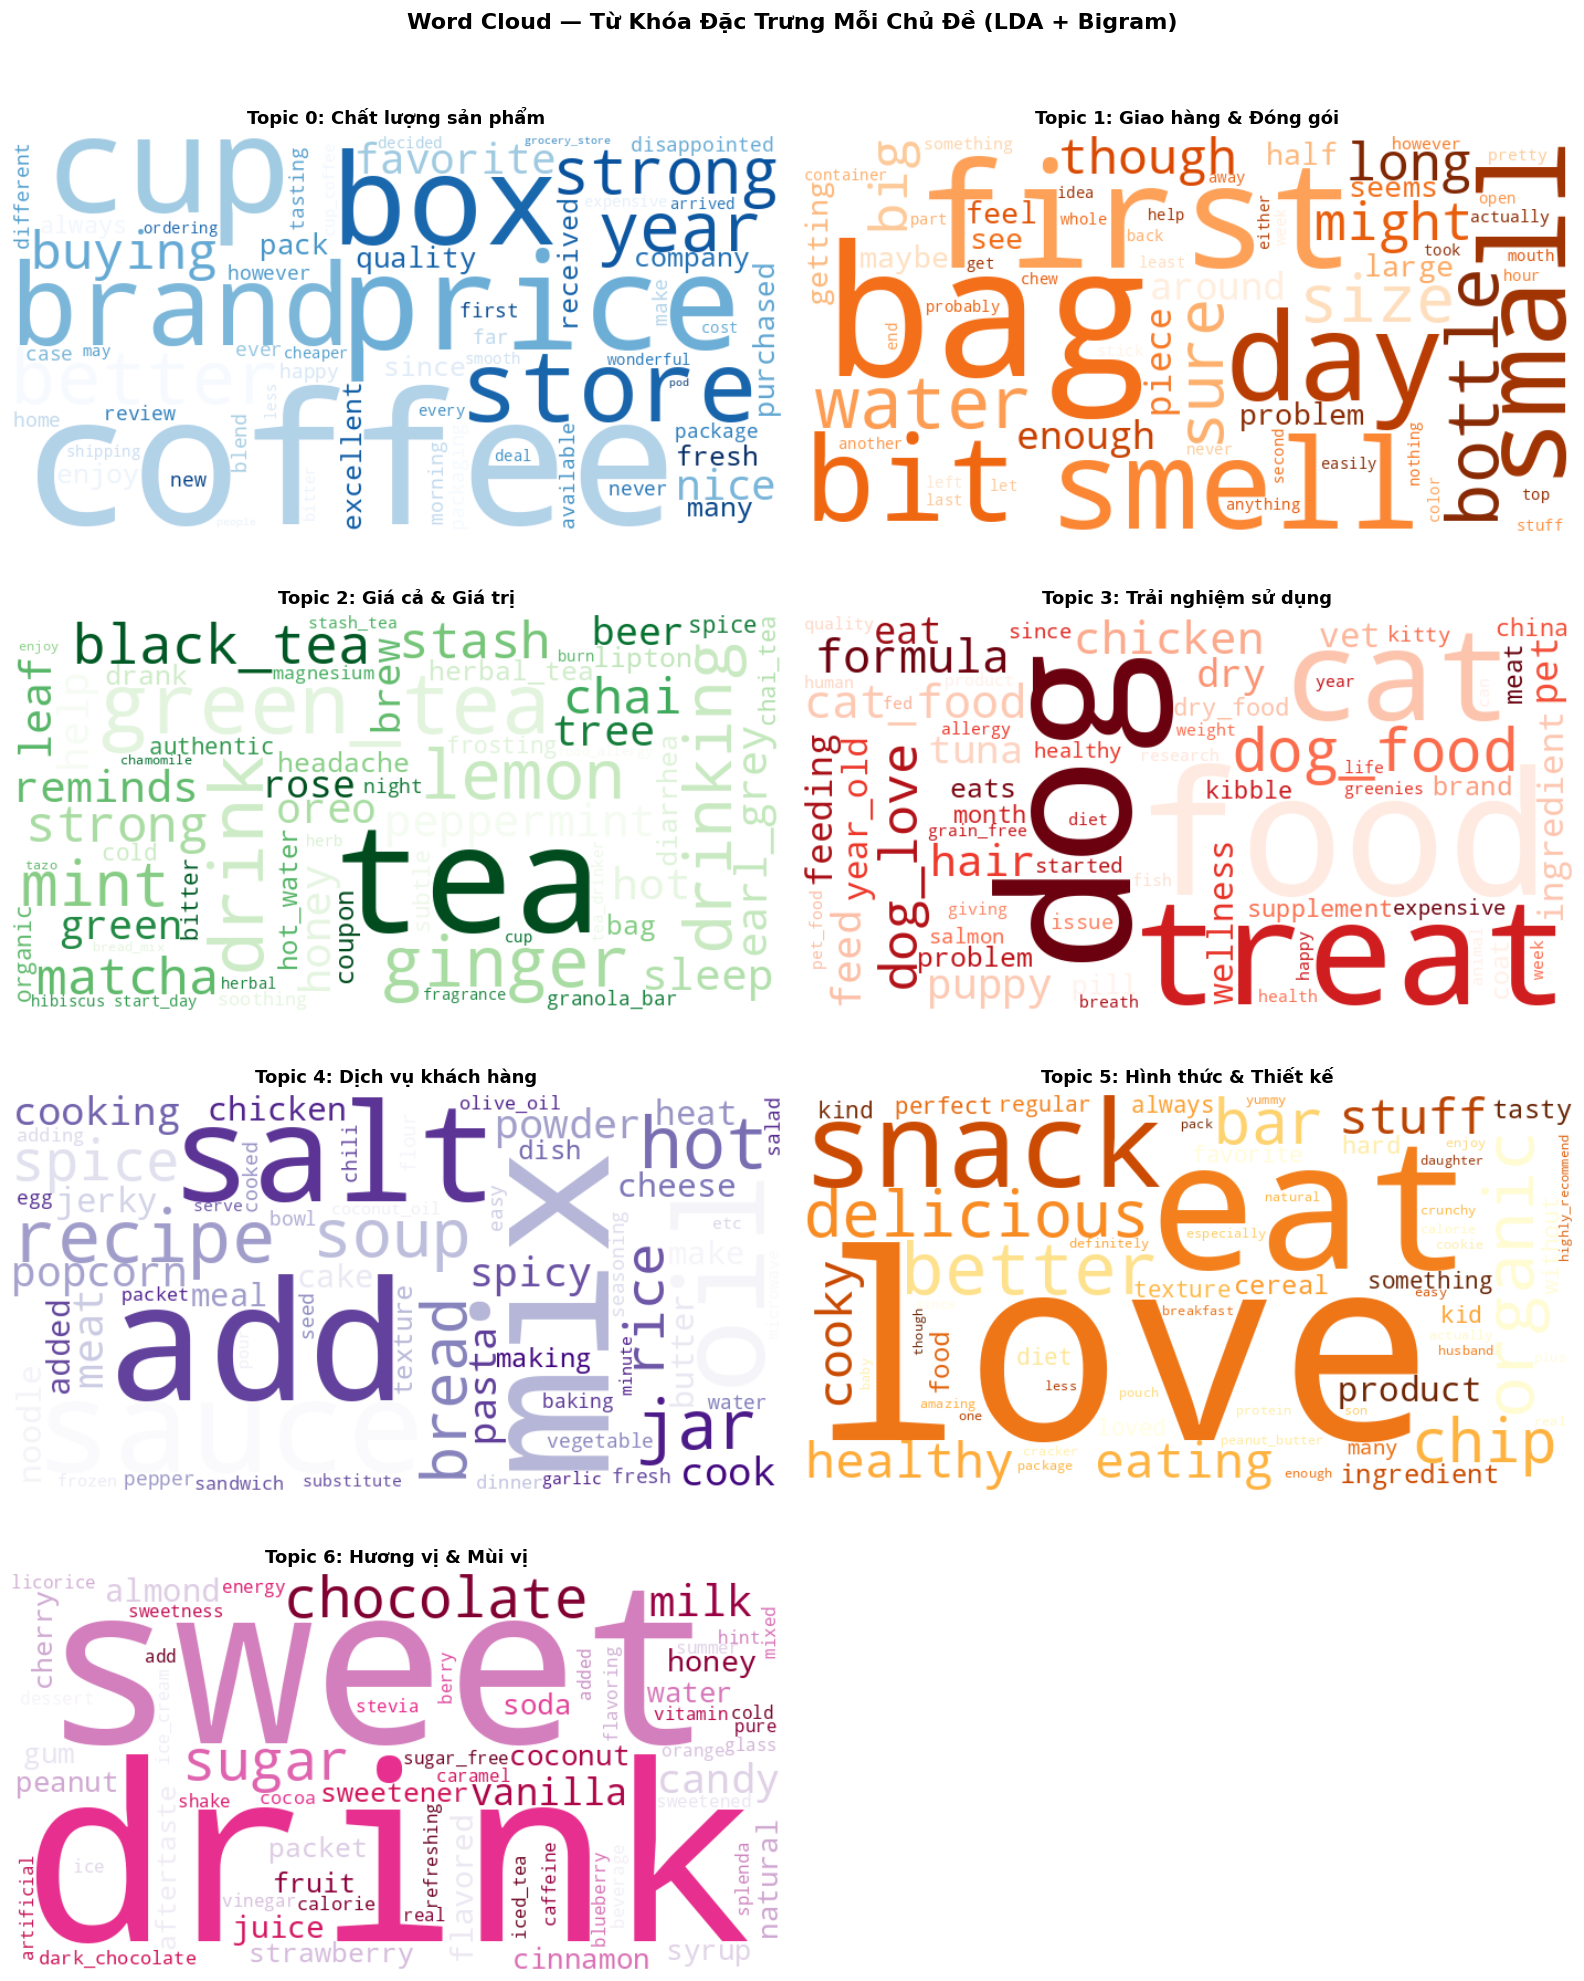

In [ ]:
# 10.3 — Word Cloud mỗi topic
WC_MAPS = ['Blues','Oranges','Greens','Reds','Purples','YlOrBr','PuRd','GnBu']
n_rows  = (NUM_TOPICS + 1) // 2
fig2, axes = plt.subplots(n_rows, 2, figsize=(16, 5*n_rows))
axes = axes.flatten()

for i in range(NUM_TOPICS):
    freq = dict(lda_model.show_topic(i, topn=60))
    wc   = WordCloud(width=700, height=360, background_color='white',
                     max_words=60, colormap=WC_MAPS[i % len(WC_MAPS)],
                     prefer_horizontal=0.85, min_font_size=10
                     ).generate_from_frequencies(freq)
    axes[i].imshow(wc, interpolation='bilinear')
    axes[i].set_title(f'Topic {i}: {TOPIC_NAMES.get(i,"")}',
                      fontsize=13, fontweight='bold', pad=8)
    axes[i].axis('off')

for j in range(NUM_TOPICS, len(axes)): axes[j].set_visible(False)
plt.suptitle('Word Cloud — Từ Khóa Đặc Trưng Mỗi Chủ Đề (LDA + Bigram)',
             fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('/content/wordcloud_lda.png', dpi=150, bbox_inches='tight')
plt.show()

#Demo

In [ ]:
# 11.1 — Lưu model & data
lda_model.save('/content/lda_model')
dictionary.save('/content/lda_dictionary.dict')
bert_model.save('/content/bert_model', serialization='pickle')
with open('/content/topic_names.pkl','wb') as f: pickle.dump(TOPIC_NAMES, f)

df_merged[['review_text','rating','sentiment','source','dominant_topic',
           'topic_probability','topic_name','brand','category','tokens']].to_csv(
    '/content/amazon_reviews_with_topics.csv', index=False, encoding='utf-8-sig')
df_bert[['review_text','rating','sentiment','bert_topic','bert_prob']].to_csv(
    '/content/bert_results.csv', index=False, encoding='utf-8-sig')

# Lưu bigram/trigram phrasers để Streamlit dùng
with open('/content/bigram.pkl','wb') as f: pickle.dump(bigram, f)
with open('/content/trigram.pkl','wb') as f: pickle.dump(trigram, f)

# Lưu BERTopic top words mỗi topic
bert_topic_words = {}
for tid in bert_model.get_topics():
    if tid == -1: continue
    bert_topic_words[int(tid)] = [(w, float(s)) for w,s in bert_model.get_topic(tid)[:10]]
with open('/content/bert_topic_words.pkl','wb') as f: pickle.dump(bert_topic_words, f)

print('✅ Đã lưu tất cả model & data')

2026-05-12 08:48:32,411 - BERTopic - WARNING: When you use `pickle` to save/load a BERTopic model,please make sure that the environments in which you saveand load the model are **exactly** the same. The version of BERTopic,its dependencies, and python need to remain the same.


✅ Đã lưu tất cả model & data


In [ ]:
# 11.2 — Tạo file app.py cho Streamlit
app_code = r'''
import streamlit as st
import pandas as pd, numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import pickle, re, os, signal, json, nltk
from gensim import corpora
from gensim.models import LdaModel
from nltk.corpus import stopwords as nltk_sw
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from collections import Counter

for p in ["punkt","punkt_tab","stopwords","wordnet"]: nltk.download(p, quiet=True)

st.set_page_config(page_title="Amazon Topic Analyzer v5", page_icon="🛒", layout="wide")

PALETTE  = ["#4C72B0","#DD8452","#55A868","#C44E52","#8172B3","#937860","#DA8BC3","#8C8C8C"]
SENT_CLR = {"Tích cực":"#2ecc71","Trung lập":"#f1c40f","Tiêu cực":"#e74c3c"}
STAR_CLR = ["#e74c3c","#e67e22","#f1c40f","#2ecc71","#3498db"]

# ════════════════════════════════════════════════════════════
# LOADERS
# ════════════════════════════════════════════════════════════
@st.cache_resource
def load_models():
    lda   = LdaModel.load("lda_model")
    dct   = corpora.Dictionary.load("lda_dictionary.dict")
    with open("topic_names.pkl","rb") as f: tnames = pickle.load(f)
    with open("bigram.pkl","rb") as f: bigram = pickle.load(f)
    with open("trigram.pkl","rb") as f: trigram = pickle.load(f)
    with open("bert_topic_words.pkl","rb") as f: bert_words = pickle.load(f)
    return lda, dct, tnames, bigram, trigram, bert_words

@st.cache_data
def load_data():
    df = pd.read_csv("amazon_reviews_with_topics.csv")
    df["sentiment"] = df["rating"].apply(
        lambda r: "Tích cực" if r>=4 else ("Tiêu cực" if r<=2 else "Trung lập"))
    return df

@st.cache_data
def load_bert_data():
    try: return pd.read_csv("bert_results.csv")
    except: return None

@st.cache_data
def load_metrics():
    try:
        with open("eval_metrics.json") as f: return json.load(f)
    except: return None

@st.cache_data
def load_intrinsic():
    try: return pd.read_csv("intrinsic_metrics.csv")
    except: return None

SW = set(nltk_sw.words("english"))
CUSTOM = {"product","item","amazon","buy","bought","one","get","got","use","used",
          "would","could","also","really","like","much","well","good","great","bad",
          "even","still","make","made","way","time","thing","work","works","worked",
          "br","href","com","www","http","https","quot","amp",
          "taste","tastes","tasted","flavor","flavour"}
SW.update(CUSTOM)
LM = WordNetLemmatizer()

def clean(text):
    text = str(text).lower()
    text = re.sub(r"<[^>]+>", " ", text)
    text = re.sub(r"http\S+|www\.\S+", " ", text)
    text = re.sub(r"&\w+;", " ", text)
    text = re.sub(r"\b\w*\d\w*\b", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    return re.sub(r"\s+", " ", text).strip()

def preprocess(text, bigram=None, trigram=None):
    tokens = [LM.lemmatize(t) for t in word_tokenize(clean(text))
              if t not in SW and len(t)>2]
    if bigram is not None: tokens = bigram[tokens]
    if trigram is not None: tokens = trigram[tokens]
    return list(tokens)

# Load
lda, dct, TNAMES, bigram, trigram, BERT_WORDS = load_models()
df = load_data()
df_bert = load_bert_data()
metrics = load_metrics()
intrinsic = load_intrinsic()
N  = lda.num_topics

# ════════════════════════════════════════════════════════════
# SIDEBAR
# ════════════════════════════════════════════════════════════
with st.sidebar:
    st.image("https://upload.wikimedia.org/wikipedia/commons/thumb/a/a9/Amazon_logo.svg/320px-Amazon_logo.svg.png", width=160)
    st.markdown("## 🛒 Amazon Topic Analyzer **v5**")
    st.markdown(f"**{len(df):,} reviews** | **{N} topics**")
    if metrics:
        st.markdown(f"📐 LDA Acc: **{metrics['lda']['accuracy']*100:.1f}%**")
        st.markdown(f"📐 BERT Acc: **{metrics['bert']['accuracy']*100:.1f}%**")
    st.markdown("---")
    sent_filter = st.multiselect("Lọc cảm xúc",
        ["Tích cực","Trung lập","Tiêu cực"],
        default=["Tích cực","Trung lập","Tiêu cực"])
    src_filter = st.multiselect("Lọc nguồn dữ liệu",
        df["source"].unique().tolist(),
        default=df["source"].unique().tolist())
    rating_range = st.slider("Khoảng rating", 1, 5, (1,5))
    st.markdown("---")
    st.markdown("### ⚙️ Điều khiển")
    if st.button("⏹️ Dừng Streamlit & chạy tiếp notebook", type="secondary", use_container_width=True):
        st.warning("Đang dừng Streamlit...")
        st.stop()
        os.kill(os.getpid(), signal.SIGTERM)

df_f = df[df["sentiment"].isin(sent_filter)
        & df["source"].isin(src_filter)
        & df["rating"].between(rating_range[0], rating_range[1])]

# ════════════════════════════════════════════════════════════
# TABS
# ════════════════════════════════════════════════════════════
tab1, tab2, tab3, tab4, tab5, tab6 = st.tabs([
    "🔍 Phân tích review", "📊 Tổng quan", "📈 So sánh Dataset",
    "🤖 BERTopic", "📐 Đánh giá mô hình", "📁 Upload Batch"
])

# ───────────────── TAB 1 — PHÂN TÍCH ─────────────────
with tab1:
    st.subheader("🔍 Phân tích chủ đề của review bất kỳ (LDA + BERT song song)")
    col_in, col_ex = st.columns([3,1])
    with col_in:
        user_text = st.text_area("Nhập review:", height=140,
            placeholder="Ví dụ: The battery life is excellent and screen is very clear...")
    with col_ex:
        st.markdown("**Thử nhanh:**")
        examples = [
            "Battery life is amazing, lasts all day easily",
            "Delivery was late and packaging completely damaged",
            "Great price for the quality, absolutely worth it",
            "Tastes delicious, fresh and very flavorful",
            "Customer service was terrible, no response for weeks",
        ]
        for ex in examples:
            if st.button(ex[:34]+"…", key=ex, use_container_width=True):
                st.session_state["user_text"] = ex
                user_text = ex

    if st.button("🔎 Phân tích ngay", type="primary"):
        if user_text and user_text.strip():
            tokens = preprocess(user_text, bigram, trigram)
            if len(tokens)<2:
                st.warning("Review quá ngắn sau tiền xử lý.")
            else:
                bow   = dct.doc2bow(tokens)
                probs = dict(lda.get_document_topics(bow, minimum_probability=0))
                scores= [probs.get(i,0.0) for i in range(N)]
                best  = int(np.argmax(scores))
                best_name = TNAMES.get(best, f"Topic {best}")

                c1,c2,c3,c4 = st.columns(4)
                c1.metric("🎯 Chủ đề chính (LDA)", best_name)
                c2.metric("📊 Độ chắc chắn", f"{scores[best]*100:.1f}%")
                c3.metric("🔤 Số token", str(len(tokens)))
                c4.metric("📐 Bigram/Trigram", str(sum(1 for t in tokens if "_" in t)))

                # Tokens hiện ra
                with st.expander("🔤 Tokens sau tiền xử lý (có bigram/trigram)", expanded=False):
                    st.write(tokens)

                # Bar chart xác suất
                fig = go.Figure(go.Bar(
                    x=[TNAMES.get(i, f"T{i}") for i in range(N)],
                    y=[s*100 for s in scores],
                    marker=dict(color=["#2ecc71" if i==best else "#4C72B0" for i in range(N)]),
                    text=[f"{s*100:.1f}%" for s in scores],
                    textposition="outside",
                    hovertemplate="%{x}: %{y:.2f}%<extra></extra>"
                ))
                fig.update_layout(
                    title="Xác suất thuộc từng chủ đề (LDA)",
                    xaxis_tickangle=-30, yaxis_title="Xác suất (%)",
                    yaxis_range=[0,110],
                    plot_bgcolor="white", paper_bgcolor="white",
                    font_family="Arial", font_size=12, height=380
                )
                st.plotly_chart(fig, use_container_width=True)

                # Top-3 topic gần nhất từ BERTopic (so khớp token với từ khóa)
                st.markdown("##### 🤖 Top chủ đề gần nhất theo BERTopic (so khớp từ khóa)")
                user_set = set(tokens)
                bert_scores = []
                for tid, words in BERT_WORDS.items():
                    w_set = set(w for w,_ in words)
                    inter = len(user_set & w_set)
                    score = sum(s for w,s in words if w in user_set)
                    bert_scores.append((tid, inter, score, words))
                bert_scores.sort(key=lambda x: (x[2], x[1]), reverse=True)
                top3 = bert_scores[:3]
                for tid, inter, score, words in top3:
                    kw = ", ".join([w for w,_ in words[:6]])
                    st.write(f"**BERTopic #{tid}** — match score: {score:.3f} ({inter} từ trùng)  \n_Keywords: {kw}_")
        else:
            st.warning("Vui lòng nhập nội dung.")

# ───────────────── TAB 2 — TỔNG QUAN ─────────────────
with tab2:
    m1,m2,m3,m4,m5 = st.columns(5)
    m1.metric("Tổng review", f"{len(df_f):,}")
    m2.metric("Rating TB", f"{df_f['rating'].mean():.2f} ⭐")
    m3.metric("Tích cực", f"{(df_f['sentiment']=='Tích cực').mean()*100:.1f}%")
    m4.metric("Tiêu cực", f"{(df_f['sentiment']=='Tiêu cực').mean()*100:.1f}%")
    m5.metric("Số chủ đề", str(N))
    st.markdown("---")

    agg = df_f.groupby("topic_name").agg(
        count=("rating","count"),
        avg_rating=("rating","mean"),
        pos_pct=("sentiment", lambda x:(x=="Tích cực").mean()*100),
        neg_pct=("sentiment", lambda x:(x=="Tiêu cực").mean()*100),
    ).round(2).reset_index().sort_values("count", ascending=False)

    ts  = df_f.groupby(["topic_name","sentiment"]).size().reset_index(name="count")
    td  = df_f["topic_name"].value_counts().reset_index(); td.columns=["topic","count"]
    hm  = df_f.groupby(["rating","topic_name"]).size().unstack(fill_value=0)
    hmp = hm.div(hm.sum(axis=1),axis=0).mul(100).round(1) if len(hm)>0 else hm

    fig = make_subplots(rows=3, cols=2,
        subplot_titles=["① Số review theo chủ đề & cảm xúc","② Phân phối chủ đề",
                        "③ Rating TB theo chủ đề","④ Heatmap chủ đề × sao",
                        "⑤ % Tích cực vs Tiêu cực","⑥ Top 15 từ phổ biến"],
        specs=[[{"type":"bar"},{"type":"pie"}],
               [{"type":"bar"},{"type":"heatmap"}],
               [{"type":"bar"},{"type":"bar"}]],
        vertical_spacing=0.11, horizontal_spacing=0.07)
    for sent,color in SENT_CLR.items():
        sub = ts[ts["sentiment"]==sent]
        fig.add_trace(go.Bar(x=sub["topic_name"], y=sub["count"], name=sent,
            marker_color=color), row=1, col=1)
    fig.add_trace(go.Pie(labels=td["topic"], values=td["count"], hole=0.4,
        marker_colors=PALETTE[:len(td)], showlegend=False), row=1, col=2)
    bc = ["#2ecc71" if r>=4 else "#e67e22" if r>=3 else "#e74c3c" for r in agg["avg_rating"]]
    fig.add_trace(go.Bar(x=agg["topic_name"], y=agg["avg_rating"], marker_color=bc,
        showlegend=False, text=agg["avg_rating"].apply(lambda x: f"{x:.2f}"),
        textposition="outside"), row=2, col=1)
    if len(hmp)>0:
        fig.add_trace(go.Heatmap(z=hmp.values, x=hmp.columns.tolist(),
            y=[f"{r}⭐" for r in hmp.index], colorscale="YlOrRd",
            text=hmp.values, texttemplate="%{text:.0f}%", textfont_size=9, showscale=False),
            row=2, col=2)
    fig.add_trace(go.Bar(x=agg["topic_name"], y=agg["pos_pct"], name="Tích cực",
        marker_color="#2ecc71"), row=3, col=1)
    fig.add_trace(go.Bar(x=agg["topic_name"], y=agg["neg_pct"], name="Tiêu cực",
        marker_color="#e74c3c"), row=3, col=1)

    all_toks = []
    for toks in df_f["tokens"].dropna():
        s = str(toks).strip("[]")
        for tok in s.split(","):
            t = tok.strip().strip("'").strip('"')
            if t: all_toks.append(t)
    top15 = Counter(all_toks).most_common(15)
    if top15:
        wds, cnts = zip(*top15)
        fig.add_trace(go.Bar(x=list(wds), y=list(cnts), showlegend=False,
            marker=dict(color=list(cnts), colorscale="Blues")), row=3, col=2)

    fig.update_layout(title_text="📊 Dashboard Tổng Hợp",
        title_font_size=15, font_family="Arial", font_size=11,
        height=1100, barmode="group",
        plot_bgcolor="white", paper_bgcolor="#f8f9fa",
        legend=dict(orientation="h", y=-0.03))
    fig.update_xaxes(tickangle=-30)
    fig.update_yaxes(showgrid=True, gridcolor="#eee")
    fig.update_yaxes(range=[0,5.8], row=2, col=1)
    st.plotly_chart(fig, use_container_width=True)

# ───────────────── TAB 3 — SO SÁNH DATASET ─────────────────
with tab3:
    st.subheader("📈 So sánh Dataset A (yasserh) vs Dataset B (Fine Food)")
    sources = df_f["source"].unique().tolist()
    c1, c2 = st.columns(2)
    for col_idx, src in enumerate(sources[:2]):
        sub = df_f[df_f["source"]==src]
        with [c1,c2][col_idx]:
            st.markdown(f"**{src}** — {len(sub):,} reviews")
            rc = sub["rating"].value_counts().sort_index().reset_index()
            rc.columns=["rating","count"]
            f2 = px.bar(rc, x="rating", y="count",
                color="rating", color_continuous_scale="RdYlGn",
                title=f"Rating — {src}")
            f2.update_layout(showlegend=False, height=300,
                plot_bgcolor="white", paper_bgcolor="white")
            st.plotly_chart(f2, use_container_width=True)

    fig3 = go.Figure()
    for src,color in zip(sources, ["#4C72B0","#DD8452"]):
        sub3 = df_f[df_f["source"]==src]["topic_name"].value_counts().reset_index()
        sub3.columns=["topic","count"]
        fig3.add_trace(go.Bar(x=sub3["topic"], y=sub3["count"], name=src,
            marker_color=color))
    fig3.update_layout(title="Phân phối chủ đề: Dataset A vs B",
        barmode="group", font_family="Arial", font_size=12,
        plot_bgcolor="white", paper_bgcolor="white", height=420,
        xaxis_tickangle=-30)
    fig3.update_yaxes(showgrid=True, gridcolor="#eee")
    st.plotly_chart(fig3, use_container_width=True)

# ───────────────── TAB 4 — BERTopic ─────────────────
with tab4:
    st.subheader("🤖 BERTopic — Kết quả từ mô hình Transformer")
    st.info("BERTopic dùng Sentence-BERT + UMAP + HDBSCAN — đã áp dụng ClassTfidf + Reduce Outliers")
    if df_bert is None:
        st.warning("Chưa có file bert_results.csv — chạy Bước 7 trong notebook trước.")
    else:
        b1,b2,b3,b4 = st.columns(4)
        b1.metric("Reviews phân tích", f"{len(df_bert):,}")
        b2.metric("Noise (-1)", f"{(df_bert['bert_topic']==-1).sum():,}")
        b3.metric("Topic tìm được", str(df_bert[df_bert['bert_topic']!=-1]['bert_topic'].nunique()))
        b4.metric("Confidence TB", f"{df_bert['bert_prob'].mean():.3f}")

        bt_dist = df_bert[df_bert['bert_topic']!=-1]['bert_topic'].value_counts().head(15).reset_index()
        bt_dist.columns=["topic","count"]
        fig4 = px.bar(bt_dist, x="topic", y="count",
            title="Top 15 BERTopic theo số document",
            color="count", color_continuous_scale="Blues")
        fig4.update_layout(plot_bgcolor="white", paper_bgcolor="white", height=380)
        st.plotly_chart(fig4, use_container_width=True)

        st.markdown("**Từ khóa top của 8 topic lớn nhất:**")
        top_topics = bt_dist["topic"].head(8).tolist()
        cols = st.columns(2)
        for idx, tid in enumerate(top_topics):
            if tid in BERT_WORDS:
                kws = BERT_WORDS[tid]
                with cols[idx%2]:
                    st.markdown(f"**BERT Topic #{tid}**")
                    kw_df = pd.DataFrame(kws, columns=["Từ khóa","Score"])
                    st.dataframe(kw_df, use_container_width=True, height=200)

        st.markdown("---")
        st.markdown("**Phân phối xác suất BERTopic:**")
        fig5 = px.histogram(df_bert[df_bert['bert_topic']!=-1],
            x="bert_prob", nbins=40, title="Histogram độ chắc chắn BERTopic",
            color_discrete_sequence=["#4C72B0"])
        fig5.update_layout(plot_bgcolor="white", paper_bgcolor="white", height=320)
        st.plotly_chart(fig5, use_container_width=True)

# ───────────────── TAB 5 — ĐÁNH GIÁ MÔ HÌNH ─────────────────
with tab5:
    st.subheader("📐 Đánh Giá Mô Hình — LDA vs BERTopic")
    st.caption("Proxy ground truth: **Sentiment** (Tích/Trung/Tiêu cực) — mỗi topic được gán = sentiment đa số")

    if metrics is None:
        st.warning("Chưa có file eval_metrics.json — chạy Bước 9 trong notebook trước.")
    else:
        # Metric cards
        st.markdown("### 🎯 Metrics chính (proxy: sentiment)")
        c1, c2 = st.columns(2)
        with c1:
            st.markdown("#### 🔵 LDA")
            mc1, mc2 = st.columns(2)
            mc1.metric("Accuracy", f"{metrics['lda']['accuracy']*100:.2f}%")
            mc2.metric("F1-score", f"{metrics['lda']['f1']*100:.2f}%")
            mc3, mc4 = st.columns(2)
            mc3.metric("Precision", f"{metrics['lda']['precision']*100:.2f}%")
            mc4.metric("Recall", f"{metrics['lda']['recall']*100:.2f}%")
        with c2:
            st.markdown("#### 🟠 BERTopic")
            mc1, mc2 = st.columns(2)
            mc1.metric("Accuracy", f"{metrics['bert']['accuracy']*100:.2f}%")
            mc2.metric("F1-score", f"{metrics['bert']['f1']*100:.2f}%")
            mc3, mc4 = st.columns(2)
            mc3.metric("Precision", f"{metrics['bert']['precision']*100:.2f}%")
            mc4.metric("Recall", f"{metrics['bert']['recall']*100:.2f}%")

        # Bar chart comparison
        st.markdown("---")
        st.markdown("### 📊 So Sánh Trực Quan")
        comp_df = pd.DataFrame([
            {"Model":"LDA","Metric":"Accuracy","Value":metrics['lda']['accuracy']*100},
            {"Model":"LDA","Metric":"Precision","Value":metrics['lda']['precision']*100},
            {"Model":"LDA","Metric":"Recall","Value":metrics['lda']['recall']*100},
            {"Model":"LDA","Metric":"F1","Value":metrics['lda']['f1']*100},
            {"Model":"BERTopic","Metric":"Accuracy","Value":metrics['bert']['accuracy']*100},
            {"Model":"BERTopic","Metric":"Precision","Value":metrics['bert']['precision']*100},
            {"Model":"BERTopic","Metric":"Recall","Value":metrics['bert']['recall']*100},
            {"Model":"BERTopic","Metric":"F1","Value":metrics['bert']['f1']*100},
        ])
        fig_m = px.bar(comp_df, x="Metric", y="Value", color="Model",
            barmode="group", text="Value",
            color_discrete_map={"LDA":"#4C72B0","BERTopic":"#DD8452"})
        fig_m.update_traces(texttemplate="%{text:.1f}%", textposition="outside")
        fig_m.update_layout(yaxis_title="Score (%)", yaxis_range=[0,105],
            plot_bgcolor="white", paper_bgcolor="white", height=400)
        st.plotly_chart(fig_m, use_container_width=True)


        # Intrinsic metrics
        if intrinsic is not None:
            st.markdown("---")
            st.markdown("### 🧮 Metrics Nội Tại (không cần label)")
            c1, c2 = st.columns([1,2])
            with c1:
                st.dataframe(intrinsic, use_container_width=True)
            with c2:
                fig_int = go.Figure()
                fig_int.add_trace(go.Bar(name="LDA", x=intrinsic["Metric"][:2],
                    y=intrinsic["LDA"][:2], marker_color="#4C72B0",
                    text=[f"{v:.3f}" for v in intrinsic["LDA"][:2]], textposition="outside"))
                fig_int.add_trace(go.Bar(name="BERTopic", x=intrinsic["Metric"][:2],
                    y=intrinsic["BERTopic"][:2], marker_color="#DD8452",
                    text=[f"{v:.3f}" for v in intrinsic["BERTopic"][:2]], textposition="outside"))
                fig_int.update_layout(title="Coherence & Topic Diversity",
                    barmode="group", plot_bgcolor="white", paper_bgcolor="white",
                    height=350)
                st.plotly_chart(fig_int, use_container_width=True)
            st.info("📌 **Coherence (c_v)**: cao hơn = topic mạch lạc hơn. **Topic Diversity**: cao hơn = topic khác nhau hơn.")

        # Topic → Sentiment mapping
        st.markdown("---")
        st.markdown("### 🗺️ Mapping Topic → Sentiment (đa số)")
        c1, c2 = st.columns(2)
        with c1:
            st.markdown("**LDA:**")
            map_lda = pd.DataFrame([
                {"Topic ID":k, "Topic name":TNAMES.get(int(k), f"T{k}"), "Predicted sentiment":v}
                for k,v in metrics['lda']['topic_to_sent'].items()
            ])
            st.dataframe(map_lda, use_container_width=True)
        with c2:
            st.markdown("**BERTopic:**")
            map_bert = pd.DataFrame([
                {"BERT Topic ID":k, "Predicted sentiment":v}
                for k,v in metrics['bert']['topic_to_sent'].items()
            ])
            st.dataframe(map_bert, use_container_width=True)

# ───────────────── TAB 6 — UPLOAD BATCH ─────────────────
with tab6:
    st.subheader("📁 Upload CSV để phân tích hàng loạt")
    st.caption("Upload file CSV có cột chứa review text → áp dụng LDA → kết quả + biểu đồ tổng hợp")

    uploaded = st.file_uploader("Chọn file CSV", type=["csv"])
    if uploaded is not None:
        try:
            df_up = pd.read_csv(uploaded)
            st.success(f"✅ Đã đọc {len(df_up):,} dòng")
            st.dataframe(df_up.head(), use_container_width=True)

            text_col = st.selectbox("Cột chứa review text:", df_up.columns.tolist())

            if st.button("🚀 Phân tích tất cả", type="primary"):
                with st.spinner(f"Đang phân tích {len(df_up):,} review..."):
                    progress = st.progress(0)
                    results = []
                    for i, row in enumerate(df_up[text_col].astype(str)):
                        tokens = preprocess(row, bigram, trigram)
                        if len(tokens) < 2:
                            results.append((-1, 0.0, "Quá ngắn"))
                            continue
                        bow = dct.doc2bow(tokens)
                        probs = dict(lda.get_document_topics(bow, minimum_probability=0))
                        if not probs:
                            results.append((-1, 0.0, "N/A"))
                            continue
                        best_id = max(probs, key=probs.get)
                        results.append((best_id, probs[best_id], TNAMES.get(best_id, f"T{best_id}")))
                        if i % max(1, len(df_up)//100) == 0:
                            progress.progress(min(i/len(df_up), 1.0))
                    progress.progress(1.0)

                df_up["topic_id"]    = [r[0] for r in results]
                df_up["topic_prob"]  = [r[1] for r in results]
                df_up["topic_name"]  = [r[2] for r in results]

                st.success("✅ Hoàn thành!")

                # Stats
                c1,c2,c3 = st.columns(3)
                c1.metric("Tổng review", f"{len(df_up):,}")
                c2.metric("Phân loại OK", f"{(df_up['topic_id']>=0).sum():,}")
                c3.metric("Confidence TB", f"{df_up[df_up['topic_id']>=0]['topic_prob'].mean():.3f}")

                # Phân phối topic
                td_up = df_up[df_up["topic_id"]>=0]["topic_name"].value_counts().reset_index()
                td_up.columns = ["Chủ đề","Số review"]
                fig_up = px.pie(td_up, values="Số review", names="Chủ đề",
                    title="Phân phối chủ đề trong file đã upload",
                    color_discrete_sequence=PALETTE, hole=0.4)
                st.plotly_chart(fig_up, use_container_width=True)

                fig_bar = px.bar(td_up, x="Chủ đề", y="Số review",
                    title="Số review theo chủ đề",
                    color="Số review", color_continuous_scale="Blues")
                fig_bar.update_layout(plot_bgcolor="white", paper_bgcolor="white", height=400)
                st.plotly_chart(fig_bar, use_container_width=True)

                # Bảng kết quả
                st.markdown("### 📋 Bảng kết quả")
                st.dataframe(df_up, use_container_width=True, height=400)

                # Tải về
                csv = df_up.to_csv(index=False, encoding="utf-8-sig").encode("utf-8-sig")
                st.download_button("⬇️ Tải kết quả CSV", csv,
                    "batch_results.csv", "text/csv", use_container_width=True)
        except Exception as e:
            st.error(f"Lỗi khi đọc file: {e}")
    else:
        st.info("👆 Upload file CSV để bắt đầu. File cần có ít nhất 1 cột chứa review text.")
'''

with open('/content/app.py', 'w', encoding='utf-8') as f:
    f.write(app_code)
print('✅ Đã tạo file app.py — Streamlit 6 tab')

✅ Đã tạo file app.py — Streamlit 6 tab


In [ ]:
# 11.3 — Chạy Streamlit qua ngrok
!pip install streamlit pyngrok -q

NGROK_TOKEN = '3Da8C37r0maopLgSfxZMaDpbrXv_wYRgiWLTYfFmn2FpdWWJ'  # ← Điền token tại https://dashboard.ngrok.com

if NGROK_TOKEN:
    from pyngrok import ngrok
    import subprocess, time
    ngrok.set_auth_token(NGROK_TOKEN)
    proc = subprocess.Popen(['streamlit','run','/content/app.py',
                             '--server.port','8501','--server.headless','true'])
    time.sleep(3)
    public_url = ngrok.connect(8501)
    print(f'🌐 Demo tại: {public_url}')
    print('→ Bấm nút "Dừng Streamlit" trong sidebar để chạy tiếp Bước 12')
else:
    print('⚠️  Điền NGROK_TOKEN để chạy trong Colab.')
    print('   Đăng ký miễn phí: https://ngrok.com')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 66.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 68.4 MB/s eta 0:00:00
🌐 Demo tại: NgrokTunnel: "https://uneven-catty-uninsured.ngrok-free.dev" -> "http://localhost:8501"
→ Bấm nút "Dừng Streamlit" trong sidebar để chạy tiếp Bước 12


#Tóm tắt & tải kết quả

In [ ]:
print('='*70)
print('TÓM TẮT KẾT QUẢ PHÂN TÍCH — Version 5 (Final)')
print('='*70)
print(f'Dataset A : {len(df_a):,} reviews')
print(f'Dataset B : {len(df_b):,} reviews')
print(f'Merged    : {len(df_merged):,} reviews')
print()
print(f'🤖 LDA      : {NUM_TOPICS} topics (Coherence c_v = {coherence_lda:.4f})')
print(f'🔬 BERTopic : {len(bert_topics_words)} topics (Coherence c_v = {coherence_bert:.4f})')
print()
print(f'📐 Accuracy (proxy=sentiment):')
print(f'   LDA       : {eval_lda["accuracy"]*100:.2f}%  | F1: {eval_lda["f1"]*100:.2f}%')
print(f'   BERTopic  : {eval_bert["accuracy"]*100:.2f}% | F1: {eval_bert["f1"]*100:.2f}%')
print()
print('Phân phối topic LDA:')
for i in range(NUM_TOPICS):
    sub = df_merged[df_merged['dominant_topic']==i]
    pct = len(sub)/len(df_merged)*100
    pos = (sub['sentiment']=='Tích cực').mean()*100
    print(f'  {TOPIC_NAMES.get(i):24s}: {len(sub):5,} ({pct:4.1f}%) | '
          f'Rating {sub["rating"].mean():.2f}⭐ | Tích cực {pos:.0f}%')

TÓM TẮT KẾT QUẢ PHÂN TÍCH — Version 5 (Final)
Dataset A : 1,177 reviews
Dataset B : 50,000 reviews
Merged    : 50,866 reviews

🤖 LDA      : 7 topics (Coherence c_v = 0.5414)
🔬 BERTopic : 15 topics (Coherence c_v = 0.5014)

📐 Accuracy (proxy=sentiment):
   LDA       : 78.35%  | F1: 68.84%
   BERTopic  : 78.71% | F1: 69.33%

Phân phối topic LDA:
  Chất lượng sản phẩm     : 23,374 (46.0%) | Rating 4.15⭐ | Tích cực 77%
  Giao hàng & Đóng gói    : 8,488 (16.7%) | Rating 3.85⭐ | Tích cực 68%
  Giá cả & Giá trị        :   538 ( 1.1%) | Rating 4.33⭐ | Tích cực 79%
  Trải nghiệm sử dụng     : 1,950 ( 3.8%) | Rating 4.30⭐ | Tích cực 81%
  Dịch vụ khách hàng      : 2,397 ( 4.7%) | Rating 4.47⭐ | Tích cực 86%
  Hình thức & Thiết kế    : 13,324 (26.2%) | Rating 4.44⭐ | Tích cực 86%
  Hương vị & Mùi vị       :   795 ( 1.6%) | Rating 4.15⭐ | Tích cực 76%


In [ ]:
from google.colab import files
import os

output_files = [
    '/content/amazon_reviews_with_topics.csv',
    '/content/bert_results.csv',
    '/content/eval_metrics.json',
    '/content/intrinsic_metrics.csv',
    '/content/app.py',
    '/content/lda_visualization.html',
    '/content/dashboard_tong_hop.html',
    '/content/metrics_compare.html',
    '/content/intrinsic_metrics.html',
    '/content/eda_rating_compare.html',
    '/content/eda_wordcount_compare.html',
    '/content/coherence_score.html',
    '/content/bert_barchart.html',
    '/content/bert_topic_map.html',
    '/content/bert_heatmap.html',
    '/content/top_words.html',
    '/content/wordcloud_lda.png',
]
for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f'  ✅ {os.path.basename(f)}')
    else:
        print(f'  ⚠️  Chưa có: {os.path.basename(f)}')
print('\n🎓 Hoàn thành — Đồ án CN3 VKU (v5)')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ amazon_reviews_with_topics.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ top_words.html


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ wordcloud_lda.png

🎓 Hoàn thành — Đồ án CN3 VKU (v5)


In [ ]:
# BONUS: Tạo gói ZIP để chạy lại Streamlit sau này (không cần chạy lại notebook)
import shutil, os

os.makedirs('/content/streamlit_package', exist_ok=True)

REQUIRED_FILES = [
    # Bắt buộc cho Streamlit
    'app.py',
    'lda_model', 'lda_model.expElogbeta.npy', 'lda_model.id2word', 'lda_model.state',
    'lda_dictionary.dict',
    'topic_names.pkl', 'bigram.pkl', 'trigram.pkl', 'bert_topic_words.pkl',
    'amazon_reviews_with_topics.csv',
    # Cho Tab 4 & 5
    'bert_results.csv', 'eval_metrics.json', 'intrinsic_metrics.csv',
]

print('📦 Đang gom file...')
for f in REQUIRED_FILES:
    src = f'/content/{f}'
    if os.path.exists(src):
        shutil.copy(src, f'/content/streamlit_package/{f}')
        print(f'  ✅ {f}')
    else:
        print(f'  ⚠️  Không tìm thấy: {f}')

# Nén thành 1 file zip
shutil.make_archive('/content/streamlit_package', 'zip', '/content/streamlit_package')
size_mb = os.path.getsize('/content/streamlit_package.zip') / (1024*1024)
print(f'\n📦 Đã nén: streamlit_package.zip ({size_mb:.2f} MB)')

# Tải về máy
from google.colab import files
files.download('/content/streamlit_package.zip')
print('\n🎉 Tải về xong — Lưu file zip này lại để chạy Streamlit lần sau!')

📦 Đang gom file...
  ✅ app.py
  ✅ lda_model
  ✅ lda_model.expElogbeta.npy
  ✅ lda_model.id2word
  ✅ lda_model.state
  ✅ lda_dictionary.dict
  ✅ topic_names.pkl
  ✅ bigram.pkl
  ✅ trigram.pkl
  ✅ bert_topic_words.pkl
  ✅ amazon_reviews_with_topics.csv
  ✅ bert_results.csv
  ✅ eval_metrics.json
  ✅ intrinsic_metrics.csv

📦 Đã nén: streamlit_package.zip (16.59 MB)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


🎉 Tải về xong — Lưu file zip này lại để chạy Streamlit lần sau!
